In [4]:
import sys
import warnings
import torch
import torch.nn             as nn
import snntorch             as snn
import matplotlib.pyplot    as plt
import numpy                as np
from torchvision            import datasets, transforms

from torch.utils.data       import DataLoader
from tqdm                   import tqdm
from pathlib                import Path

# =============================================================
# General setup
# =============================================================
# Toggle stochastic computing in neuron decays/mults
USE_SC_DECAY = True             # set False to fall back to arithmetic
SC_LENGTH    = 256              # stochastic bitstream length (trade-off: accuracy vs. speed)
warnings.filterwarnings("ignore")
plt.style.use('dark_background')

# =============================================================
# Configuration
# =============================================================
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# LENGTH      = 64                 # for SC experiments (not used in parity path)
INPUT_SIZE  = 256
HIDDEN_SIZE = 256
OUTPUT_SIZE = 10
TIME_STEPS  = 10
BATCH_SIZE  = 128
EPOCHS      = 1
LR          = 1e-3

THRESHOLD   = torch.tensor(1.0 , device=DEVICE)
BETA        = torch.tensor(0.98, device=DEVICE)
ALPHA       = torch.tensor(0.90, device=DEVICE)

# =============================================================
# Fixed-point state config (used in VerilogNeuron)
# =============================================================
USE_FIXED_STATES = True         # revert to float adds/subs for parity; fixed add/sub helpers remain available   # True -> use n-bit fixed add/sub in neuron updates
FIXED_TOTAL_BITS = 16           # Use extra headroom for sums (Q6.10)
FIXED_FRAC_BITS  = 7            # 10 fractional bits -> ~±32 range in 16-bit two's complement
FIXED_ADD_MODE   = "saturate"   # "saturate" or "wrap"  # "saturate" or "wrap"

# =============================================================
# Helper: fixed-point quantization (for weight buffers)
# =============================================================

# -------- Stochastic Computing helpers (unipolar, vectorized) --------

def sc_unipolar_mul(a: torch.Tensor, b: torch.Tensor, L: int = SC_LENGTH) -> torch.Tensor:
    """Unipolar SC multiplication ~ E[AND(S_a, S_b)] ≈ a*b.
    a, b in [0,1], arbitrary shape (broadcasted). Returns same shape as broadcast.
    Vectorized by generating streams of shape [L, *shape].
    """
    # Clamp to [0,1] to be valid probabilities
    a       = a.clamp(0.0, 1.0)
    b       = b.clamp(0.0, 1.0)
    shape   = torch.broadcast_shapes(a.shape, b.shape)
    # Expand to common shape
    a_exp   = a.expand(shape)
    b_exp   = b.expand(shape)
    # Generate stochastic bitstreams
    U1      = torch.rand((L,) + shape, device=a.device)
    U2      = torch.rand((L,) + shape, device=a.device)
    S1      = (U1 < a_exp)
    S2      = (U2 < b_exp)
    AND     = (S1 & S2).float()
    return AND.mean(dim=0)

def sc_unipolar_scale(x: torch.Tensor, s: torch.Tensor, L: int = SC_LENGTH) -> torch.Tensor:
    """Scale x by scalar/tensor s via unipolar SC: returns ~ x*s, assuming x in [0,1]."""
    return sc_unipolar_mul(x, s, L)

def to_unipolar(x: torch.Tensor, lo: float = 0.0, hi: float = 1.0) -> torch.Tensor:
    """Map x to [0,1] range for SC. Assumes threshold=1; otherwise rescale appropriately."""
    return ((x - lo) / max(1e-8, hi - lo)).clamp(0.0, 1.0)

def from_unipolar(p: torch.Tensor, lo: float = 0.0, hi: float = 1.0) -> torch.Tensor:
    """Inverse map from [0,1] back to value domain."""
    return p * (hi - lo) + lo

# =============================================================
# Rate encoder
# =============================================================

def stochastic_rate_encode(x: torch.Tensor, num_steps: int = TIME_STEPS) -> torch.Tensor:
    """Convert static images in [0,1] to spike trains (T, B, N)."""
    # x: [B, N]
    x               = x.float().unsqueeze(1).expand(-1, num_steps, -1)  # [B, T, N]
    return (torch.rand_like(x) < x).float().permute(1, 0, 2)  # [T, B, N]

def set_seed(seed: int = 0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(0)

# -------- End SC helpers --------

# Existing fixed-point helpers

# def save_one_input_batch(batch_number: int | None = 0, data_loader: torch.Tensor = torch.Tensor()):
#     x, y            = next(iter(data_loader))
#     x_rand          = stochastic_rate_encode(x)

#     x_rand[0, batch_number, :]
#     with open(f"MNIST_{y[batch_number]}.txt", "w") as f:
#         for row in x_rand[:, 0, :]:
#             for col in row:
#                 f.write(f"{int(col)}\n")

def tensor_to_coe(t: torch.Tensor,
                  path: str | Path = "init.coe",
                  bit_width: int | None = 16,
                  radix: int = 2,
                  per_line: int = 16,
                  flatten: str = "row"):
    """
    Save a tensor of signed integers to a Xilinx .coe file.

    - t: integer tensor (any shape). CUDA ok.
    - path: output .coe path.
    - bit_width: number of bits (None -> auto from {8,16,32,64}).
    - radix: 2 (binary) or 16 (hex).
    - per_line: how many values per line in the vector.
    - flatten: "row" (C-order) or "col" (column-major-like) flattening.
    """
    if t.is_cuda:
        t = t.cpu()

    if torch.is_floating_point(t):
        raise TypeError("Input tensor must be integer-typed.")
    t = t.to(torch.int64)

    # Auto-select bit width if needed
    if bit_width is None:
        mins = int(t.min().item())
        maxs = int(t.max().item())
        def fits(n):  # signed range in two's complement
            return (mins >= -(1 << (n - 1))) and (maxs < (1 << (n - 1)))
        for n in (8, 16, 32, 64):
            if fits(n):
                bit_width = n
                break
        else:
            raise ValueError("Values do not fit in 64-bit signed range.")

    if radix not in (2, 16):
        raise ValueError("radix must be 2 (binary) or 16 (hex).")

    mask = (1 << bit_width) - 1
    # Choose flattening order
    if t.ndim == 1:
        flat = t
    else:
        flat = t.reshape(-1) if flatten == "row" else t.transpose(0, 1).reshape(-1)

    # Format each value in two's complement with fixed width
    if radix == 2:
        fmt_width   = bit_width
        to_str      = lambda v: format((int(v) & mask), f"0{fmt_width}b")
    else:  # radix == 16
        fmt_width   = (bit_width + 3) // 4  # hex digits
        to_str      = lambda v: format((int(v) & mask), f"0{fmt_width}X")

    vals = [to_str(v) for v in flat]

    # Build COE text
    header = [
        f"memory_initialization_radix={radix};",
        "memory_initialization_vector="
    ]
    body_lines = []
    for i in range(0, len(vals), per_line):
        chunk       = vals[i:i+per_line]
        is_last     = (i + per_line) >= len(vals)
        if is_last:
            body_lines.append(", ".join(chunk) + ";")
        else:
            body_lines.append(", ".join(chunk) + ",")

    text = "\n".join(header + body_lines) + "\n"

    # Write file
    path            = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding="utf-8")
    return str(path), bit_width, len(vals)

def float_to_fixed(x: torch.Tensor, total_bits: int = 16, frac_bits: int = 15) -> torch.Tensor:
    """Convert float tensor to fixed-point signed integer representation."""
    max_val         = (1 << (total_bits - 1)) - 1
    min_val         = -(1 << (total_bits - 1))
    scale           = 1 << frac_bits
    fixed           = (x * scale).round().clamp(min_val, max_val)
    return fixed.to(torch.int32)

def fixed_to_float(x: torch.Tensor, frac_bits: int = 15) -> torch.Tensor:
    """Convert fixed-point signed integer tensor back to float."""
    return x.to(torch.float32) / float(1 << frac_bits)

# =============================================================
# n-bit fixed-point add / sub (two's complement)
# =============================================================

def _signed_limits(nbits: int):
    if nbits < 2:
        raise ValueError("nbits must be >= 2 for signed two's complement.")
    maxv            = (1 << (nbits - 1)) - 1
    minv            = -(1 << (nbits - 1))
    return minv, maxv

def _wrap_to_nbits(x: torch.Tensor, nbits: int) -> torch.Tensor:
    """Wrap integer tensor x to signed two's complement in nbits."""
    mask            = (1 << nbits) - 1
    x               = x.to(torch.int64) & mask
    sign_bit        = 1 << (nbits - 1)
    x               = torch.where(x >= sign_bit, x - (1 << nbits), x)
    return x.to(torch.int64)

def fixed_add(
    a_int: torch.Tensor,
    b_int: torch.Tensor,
    nbits: int,
    mode: str = "saturate"
) -> torch.Tensor:
    """
    Add two fixed-point *integer representations* (same frac_bits) with n-bit result.

    a_int, b_int: integer tensors (e.g., output of float_to_fixed)
    nbits: total fixed-point bit width (including sign)
    mode: "saturate" (default) or "wrap"
    """
    a_int           = a_int.to(torch.int64)
    b_int           = b_int.to(torch.int64)
    s               = a_int + b_int

    if mode == "wrap":
        return _wrap_to_nbits(s, nbits).to(torch.int32)

    if mode == "saturate":
        minv, maxv  = _signed_limits(nbits)
        return s.clamp(minv, maxv).to(torch.int32)

    raise ValueError("mode must be 'saturate' or 'wrap'")

def fixed_sub(
    a_int: torch.Tensor,
    b_int: torch.Tensor,
    nbits: int,
    mode: str = "saturate"
) -> torch.Tensor:
    """
    Subtract two fixed-point *integer representations* with n-bit result.
    """
    return fixed_add(a_int, -b_int.to(torch.int64), nbits=nbits, mode=mode)

def fixed_align_frac(
    x_int: torch.Tensor,
    from_frac_bits: int,
    to_frac_bits: int,
    nbits: int,
    mode: str = "saturate"
) -> torch.Tensor:
    """
    Re-align integer fixed-point value from one fractional precision to another.

    Example: convert Q(?, from_frac_bits) -> Q(?, to_frac_bits)
    """
    x_int           = x_int.to(torch.int64)
    shift           = to_frac_bits - from_frac_bits
    if shift == 0:
        return x_int.to(torch.int32)

    if shift > 0:  # up-scale: left shift, then clip/wrap
        y           = x_int << shift
    else:          # down-scale: arithmetic right shift (round-to-nearest optional)
        # simple arithmetic shift (floor toward -inf)
        y           = x_int >> (-shift)

    if mode == "wrap":
        return _wrap_to_nbits(y, nbits).to(torch.int32)
    minv, maxv      = _signed_limits(nbits)
    return y.clamp(minv, maxv).to(torch.int32)

# =============================================================
# Learnable neuron wrappers (software)
# =============================================================

class LearnableLIF(snn.Leaky):
    def __init__(self, beta_init: torch.Tensor):
        super().__init__(beta=beta_init)
        # Register as a learnable parameter (clamped in forward)
        self.beta = nn.Parameter(beta_init.clone().detach().to(DEVICE))

    def forward(self, input_, mem):
        self.beta.data.clamp_(0.01, 0.99)
        return super().forward(input_, mem)


class LearnableSynaptic(snn.Synaptic):
    def __init__(self, alpha_init: torch.Tensor, beta_init: torch.Tensor):
        super().__init__(alpha=alpha_init, beta=beta_init)
        self.alpha      = nn.Parameter(alpha_init.clone().detach().to(DEVICE))
        self.beta       = nn.Parameter(beta_init.clone().detach().to(DEVICE))

    def forward(self, input_, syn, mem):
        self.alpha.data.clamp_(0.01, 0.99)
        self.beta.data.clamp_(0.01, 0.99)
        return super().forward(input_, syn, mem)

# =============================================================
# Model selector (software path)
# =============================================================

def return_model(MODEL_NAME: str, **kwargs) -> nn.Module:
    name      = MODEL_NAME.strip().lower()
    beta      = kwargs.get("BETA", torch.tensor(0.95, device=DEVICE))
    alpha     = kwargs.get("ALPHA", torch.tensor(1.00, device=DEVICE))
    threshold = kwargs.get("THRESHOLD", torch.tensor(1.00, device=DEVICE))

    if name == 'lif':
        return LearnableLIF(beta_init=beta)
    elif name == 'synaptic':
        return LearnableSynaptic(alpha_init=alpha, beta_init=beta)
    elif name == 'if':
        # snntorch's IF neuron is IF (no leak)
        return snn.Leaky(beta=torch.as_tensor(1.0, device=DEVICE), threshold=threshold, reset_mechanism="zero")
    else:
        raise ValueError(f"Unknown model: {MODEL_NAME}")

# =============================================================
# Software SNN (reference)
# =============================================================

class SoftwareSNN(nn.Module):
    def __init__(self,
                 INPUT_SIZE : int,
                 HIDDEN_SIZE: int,
                 OUTPUT_SIZE: int,
                 MODEL_NAME : str,
                 BETA_INIT  : torch.Tensor = BETA,
                 ALPHA_INIT : torch.Tensor = ALPHA,
                 THRESHOLD  : torch.Tensor = THRESHOLD) -> None:
        super().__init__()
        self.MODEL_NAME = MODEL_NAME.strip().lower()

        self.lif1   = return_model(MODEL_NAME=self.MODEL_NAME, BETA=BETA_INIT, ALPHA=ALPHA_INIT, THRESHOLD=THRESHOLD)
        self.lif2   = return_model(MODEL_NAME=self.MODEL_NAME, BETA=BETA_INIT, ALPHA=ALPHA_INIT, THRESHOLD=THRESHOLD)

        self.fc1    = nn.Linear(INPUT_SIZE, HIDDEN_SIZE, bias=False)
        self.fc2    = nn.Linear(HIDDEN_SIZE, OUTPUT_SIZE, bias=False)

    def forward(self, x: torch.Tensor, stdp: bool = False, lr: float = 1e-3) -> torch.Tensor:
        # x: [T, B, N]
        B = x.size(1)
        if self.MODEL_NAME == 'synaptic':
            syn1 = torch.zeros(B, self.fc1.out_features, device=x.device)
            mem1 = torch.zeros(B, self.fc1.out_features, device=x.device)
            syn2 = torch.zeros(B, self.fc2.out_features, device=x.device)
            mem2 = torch.zeros(B, self.fc2.out_features, device=x.device)
        else:
            mem1 = torch.zeros(B, self.fc1.out_features, device=x.device)
            mem2 = torch.zeros(B, self.fc2.out_features, device=x.device)

        spk2_rec  = []
        spk1_prev = torch.zeros(B, self.fc1.out_features, device=x.device)
        spk2_prev = torch.zeros(B, self.fc2.out_features, device=x.device)

        for t in range(x.size(0)):
            cur1 = self.fc1(x[t])
            if self.MODEL_NAME == 'synaptic':
                spk1, syn1, mem1 = self.lif1(cur1, syn1, mem1)
            else:
                spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            if self.MODEL_NAME == 'synaptic':
                spk2, syn2, mem2 = self.lif2(cur2, syn2, mem2)
            else:
                spk2, mem2 = self.lif2(cur2, mem2)

            spk2_rec.append(spk2)

            if stdp:
                pre, post           = spk1.detach(), spk2.detach()
                pre_prev, post_prev = spk1_prev.detach(), spk2_prev.detach()
                # anti-Hebbian / Hebbian pair-based toy rule
                dw = lr * (torch.bmm(post_prev.unsqueeze(2), pre.unsqueeze(1)) -
                           torch.bmm(post.unsqueeze(2), pre_prev.unsqueeze(1)))
                self.fc2.weight.data += dw.mean(0)
                self.fc2.weight.data.clamp_(-1.0, 1.0)
                spk1_prev = spk1
                spk2_prev = spk2

        return torch.stack(spk2_rec)  # [T, B, C]

# =============================================================
# Stateless hardware neuron (parity with software equations)
# =============================================================

class VerilogNeuron(nn.Module):
    """Stateless neuron used by the hardware simulator.

    Implements IF / LIF / Synaptic with arithmetic or stochastic-computing-based decays.
    """
    def __init__(self, threshold: float = 1.0, alpha: float = 0.9, beta: float = 0.9,
                 mode: str = "lif", reset_to_zero: bool = True,
                 use_sc: bool = USE_SC_DECAY, sc_length: int = SC_LENGTH,
                 use_fixed_states: bool = USE_FIXED_STATES,
                 nbits: int = FIXED_TOTAL_BITS, frac_bits: int = FIXED_FRAC_BITS,
                 add_mode: str = FIXED_ADD_MODE):
        super().__init__()
        self.threshold      = float(threshold)
        self.alpha          = float(alpha)
        self.beta           = float(beta)
        self.mode           = mode
        self.reset_to_zero  = reset_to_zero
        self.use_sc         = use_sc
        self.sc_length      = sc_length
        # fixed-point controls
        self.use_fixed      = use_fixed_states
        self.nbits          = int(nbits)
        self.frac_bits      = int(frac_bits)
        self.add_mode       = str(add_mode)

    def _decay(self, v: torch.Tensor, alpha: float) -> torch.Tensor:
        if not self.use_sc:
            return alpha * v
        # SC path assumes v in [0, threshold]; map to [0,1], apply SC mul, map back
        v_u = to_unipolar(v, 0.0, self.threshold)
        a_t = torch.as_tensor(alpha, device=v.device, dtype=v.dtype)
        dec_u = sc_unipolar_scale(v_u, a_t, self.sc_length)
        return from_unipolar(dec_u, 0.0, self.threshold)

    def _i_decay(self, I: torch.Tensor, beta: float) -> torch.Tensor:
        if not self.use_sc:
            return beta * I
        I_u = to_unipolar(I, 0.0, self.threshold)
        b_t = torch.as_tensor(beta, device=I.device, dtype=I.dtype)
        dec_u = sc_unipolar_scale(I_u, b_t, self.sc_length)
        return from_unipolar(dec_u, 0.0, self.threshold)

    def forward(self, x: torch.Tensor, v_mem: torch.Tensor, I_t: torch.Tensor | None = None):
        # x, v_mem: [B]; I_t: [B] if synaptic. Inputs are assumed in [0, threshold].
        if not self.use_fixed:
            # --- original float path (unchanged) ---
            if self.mode == "if":
                v_next  = v_mem + x
            elif self.mode == "lif":
                decay   = v_mem * self.alpha
                v_next  = decay + x
            elif self.mode == "synaptic":
                i_decay = I_t * self.beta
                I_next  = i_decay + x
                v_decay = v_mem * self.alpha
                v_next  = v_decay + I_next
            else:
                raise ValueError("mode must be 'if' | 'lif' | 'synaptic'")

            # Saturation and threshold
            v_next = v_next.clamp(0.0, self.threshold)
            spk = (v_next >= self.threshold).float()
            if self.reset_to_zero:
                v_next = torch.where(spk.bool(), torch.zeros_like(v_next), v_next)
            else:
                v_next = torch.where(spk.bool(), v_next - self.threshold, v_next)

            if self.mode == "synaptic":
                I_next = torch.where(spk.bool(), torch.zeros_like(I_next), I_next)
                return spk, v_next, I_next
            return spk, v_next

        # --- fixed-point path for adds/subs (disabled by default; set USE_FIXED_STATES=True to enable) ---
        # Work in Q(nbits, frac_bits) for adds/subs; decays remain float/SC then quantized.
        scale = 1 << self.frac_bits
        thr_q = int(round(self.threshold * scale))

        # Quantize inputs/states
        x_q = float_to_fixed(x, total_bits=self.nbits, frac_bits=self.frac_bits)
        v_q = float_to_fixed(v_mem, total_bits=self.nbits, frac_bits=self.frac_bits)

        if self.mode == "if":
            # v_next_q = v_q + x_q (n-bit add)
            v_next_q = fixed_add(v_q, x_q, nbits=self.nbits, mode=self.add_mode)

        elif self.mode == "lif":
            # decay in float/SC, then quantize, then add in fixed
            vdec_f      = self._decay(v_mem, self.alpha)
            vdec_q      = float_to_fixed(vdec_f, total_bits=self.nbits, frac_bits=self.frac_bits)
            v_next_q    = fixed_add(vdec_q, x_q, nbits=self.nbits, mode=self.add_mode)

        elif self.mode == "synaptic":
            # Syn current path uses fixed add after float/SC decay
            Idec_f = self._i_decay(I_t, self.beta)
            Idec_q = float_to_fixed(Idec_f, total_bits=self.nbits, frac_bits=self.frac_bits)
            I_next_q = fixed_add(Idec_q, x_q, nbits=self.nbits, mode=self.add_mode)

            vdec_f  = self._decay(v_mem, self.alpha)
            vdec_q  = float_to_fixed(vdec_f, total_bits=self.nbits, frac_bits=self.frac_bits)
            v_next_q = fixed_add(vdec_q, I_next_q, nbits=self.nbits, mode=self.add_mode)
        else:
            raise ValueError("mode must be 'if' | 'lif' | 'synaptic'")

        # Clamp to [0, threshold] in fixed domain
        v_next_q = v_next_q.clamp(min=0, max=thr_q)

        # Thresholding in fixed domain
        spk = (v_next_q >= thr_q).float()

        # Reset mechanism in fixed domain
        if self.reset_to_zero:
            v_next_q = torch.where(spk.bool(), torch.zeros_like(v_next_q), v_next_q)
        else:
            # subtract threshold (pure fixed-point subtraction)
            v_next_q = torch.where(
                spk.bool(),
                fixed_sub(v_next_q, torch.as_tensor(thr_q, dtype=torch.int32, device=v_next_q.device),
                          nbits=self.nbits, mode=self.add_mode),
                v_next_q
            )

        # Dequantize back to float for the outer world
        v_next = fixed_to_float(v_next_q, frac_bits=self.frac_bits)

        if self.mode == "synaptic":
            # zero syn current on spike — in fixed domain
            I_next_q = torch.where(spk.bool(), torch.zeros_like(v_next_q), I_next_q)
            I_next = fixed_to_float(I_next_q, frac_bits=self.frac_bits)
            return spk, v_next, I_next

        return spk, v_next

# =============================================================
# Hardware simulator with per-sample states (no cross-batch bleed)
# =============================================================

class HardwareSNN(nn.Module):
    def __init__(self, fc1_weight: torch.Tensor, fc2_weight: torch.Tensor,
                 beta: torch.Tensor, alpha: torch.Tensor, threshold: torch.Tensor,
                 mode: str = 'lif', sc_length: int = SC_LENGTH, nbit: int = FIXED_TOTAL_BITS, frac_bit: int = FIXED_FRAC_BITS):
        super().__init__()
        # Quantize weights to Q1.7 like a simple fixed-point fabric
        self.register_buffer('fc1_weight_q', float_to_fixed(fc1_weight, 8, 7))  # [H, N]
        self.register_buffer('fc2_weight_q', float_to_fixed(fc2_weight, 8, 7))  # [C, H]

        # Use float arithmetic for alpha/beta/threshold to match software exactly
        self.alpha = float(alpha)
        self.beta = float(beta)
        self.threshold = float(threshold)
        self.mode = mode.strip().lower()

        self.hidden_neurons = nn.ModuleList([
            VerilogNeuron(threshold=self.threshold, alpha=self.alpha, beta=self.beta, mode=self.mode, sc_length=sc_length, nbits=nbit, frac_bits=frac_bit)
            for _ in range(HIDDEN_SIZE)
        ])
        self.output_neurons = nn.ModuleList([
            VerilogNeuron(threshold=self.threshold, alpha=self.alpha, beta=self.beta, mode=self.mode, sc_length=sc_length, nbits=nbit, frac_bits=frac_bit)
            for _ in range(OUTPUT_SIZE)
        ])

    def forward(self, x_spikes: torch.Tensor) -> torch.Tensor:
        # x_spikes: [T, B, N]
        T, B, _ = x_spikes.shape
        out_spikes = x_spikes.new_zeros(T, B, OUTPUT_SIZE)

        # Per-batch states
        v_hidden = x_spikes.new_zeros(B, HIDDEN_SIZE)
        v_out    = x_spikes.new_zeros(B, OUTPUT_SIZE)
        I_hidden = x_spikes.new_zeros(B, HIDDEN_SIZE) if self.mode == "synaptic" else None
        I_out    = x_spikes.new_zeros(B, OUTPUT_SIZE) if self.mode == "synaptic" else None

        # De-quantize weights to float for matmul (still reflects quantization noise)
        w1 = self.fc1_weight_q.float().t() / float(1 << FIXED_FRAC_BITS)  # [N, H]
        w2 = self.fc2_weight_q.float().t() / float(1 << FIXED_FRAC_BITS)  # [H, C]

        for t in range(T):
            cur1 = x_spikes[t].float() @ w1  # [B, H]

            # Hidden layer
            h_spk = x_spikes.new_zeros(B, HIDDEN_SIZE)
            for i, neuron in enumerate(self.hidden_neurons):
                if self.mode == "synaptic":
                    spk, v_hidden[:, i], I_hidden[:, i] = neuron(cur1[:, i], v_hidden[:, i], I_hidden[:, i])
                else:
                    spk, v_hidden[:, i] = neuron(cur1[:, i], v_hidden[:, i])
                h_spk[:, i] = spk

            cur2 = h_spk.float() @ w2  # [B, C]

            # Output layer
            for j, neuron in enumerate(self.output_neurons):
                if self.mode == "synaptic":
                    spk, v_out[:, j], I_out[:, j] = neuron(cur2[:, j], v_out[:, j], I_out[:, j])
                else:
                    spk, v_out[:, j] = neuron(cur2[:, j], v_out[:, j])
                out_spikes[t, :, j] = spk

        return out_spikes  # [T, B, C]

# =============================================================
# Training & evaluation
# =============================================================

def train(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer):
    model.train()
    for epoch in range(EPOCHS):
        running = 0.0
        for x, y in tqdm(loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            x_encoded = stochastic_rate_encode(x)

            optimizer.zero_grad()
            logits_over_time = model(x_encoded)          # [T,B,C] (spikes)
            output = logits_over_time.sum(0)             # sum over time -> logits [B,C]
            loss = nn.CrossEntropyLoss()(output, y)
            loss.backward()
            optimizer.step()

            running += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running/len(loader):.4f}")

def evaluate(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in tqdm(loader, desc="Evaluating"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            x_encoded = stochastic_rate_encode(x)
            logits_over_time = model(x_encoded)      # [T,B,C]
            output = logits_over_time.sum(0)         # [B,C]
            pred = output.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)
    return correct / total

# =============================================================
# Model selection prompt (console)
# =============================================================

def get_model_name() -> str:
    model_mapping = {1: 'lif', 2: 'synaptic', 3: 'if'}
    print("Select a model:")
    print("\t1. LIF")
    print("\t2. Synaptic")
    print("\t3. IF")
    print()
    sys.stdout.flush()
    prompt = "Enter your choice (1-3): "
    try:
        user_input = int(input(prompt))
        if user_input in model_mapping:
            return model_mapping[user_input]
        raise ValueError("Selection must be between 1 to 3")
    except ValueError as e:
        raise ValueError("Invalid input. Please enter 1, 2, or 3.") from e

# =============================================================
# Main
# =============================================================

# if __name__ == "__main__":
# MODEL_NAME = get_model_name()  # 'lif' | 'synaptic' | 'if'

# software_model = SoftwareSNN(INPUT_SIZE=INPUT_SIZE,
#                                 HIDDEN_SIZE=HIDDEN_SIZE,
#                                 OUTPUT_SIZE=OUTPUT_SIZE,
#                                 MODEL_NAME=MODEL_NAME,
#                                 BETA_INIT=BETA,
#                                 ALPHA_INIT=ALPHA,
#                                 THRESHOLD=THRESHOLD).to(DEVICE)

# optimizer = torch.optim.Adam(software_model.parameters(), lr=LR)

# Data loading (MNIST -> 16x16 -> flatten 256)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((16, 16)),
    transforms.Lambda(lambda x: x.view(-1))
])

train_loader = DataLoader(
    datasets.MNIST('./dataset', train=True, download=False, transform=transform),
    batch_size=BATCH_SIZE, shuffle=True
)

test_loader = DataLoader(
    datasets.MNIST('./dataset', train=False, transform=transform),
    batch_size=BATCH_SIZE
)

# Export initial (quantized) weights to COE (Q1.15 defaults in helper)
# tensor_to_coe(float_to_fixed(software_model.fc1.weight.data, FIXED_TOTAL_BITS, FIXED_FRAC_BITS), path="fc_weight_layer_1.coe")
# tensor_to_coe(float_to_fixed(software_model.fc2.weight.data, FIXED_TOTAL_BITS, FIXED_FRAC_BITS), path="fc_weight_layer_2.coe")

# save_one_input_batch(batch_number=0, data_loader=test_loader)

MODES = ["if", "lif", "synaptic"]
SC_LIST = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

def eval_hw_repeated(hardware_model_fn, loader, repeats=1, base_seed=123):
    accs = []
    for r in range(repeats):
        set_seed(base_seed + r)     # new random streams each repeat
        accs.append(evaluate(hardware_model_fn(), loader))
    return float(np.mean(accs)), float(np.std(accs))

results = {}  # mode -> dict with lists: L, mean_acc, std_acc
REPEATS = 1

NBITS = 16
FRAC  = 7

for MODE_NAME in MODES:
    print(f"\n====================")
    print(f"MODE: {MODE_NAME.upper()}")
    print(f"====================")

    # Train software model
    software_model = SoftwareSNN(
        INPUT_SIZE=INPUT_SIZE, HIDDEN_SIZE=HIDDEN_SIZE, OUTPUT_SIZE=OUTPUT_SIZE,
        MODEL_NAME=MODE_NAME, BETA_INIT=BETA, ALPHA_INIT=ALPHA, THRESHOLD=THRESHOLD
    ).to(DEVICE)

    optimizer = torch.optim.Adam(software_model.parameters(), lr=LR)
    print("Training software model...")
    train(software_model, train_loader, optimizer)

    print("Evaluating software model...")
    set_seed(0)
    sw_acc = evaluate(software_model, test_loader)
    print(f"Software Accuracy ({MODE_NAME}): {sw_acc*100:.2f}%")

    L_list, acc_mean_list, acc_std_list = [], [], []

    for sc_length in SC_LIST:
        print(f"\nSC Length: {sc_length}")

        def build_hw():
            return HardwareSNN(
                fc1_weight=software_model.fc1.weight.data.detach().to(DEVICE),
                fc2_weight=software_model.fc2.weight.data.detach().to(DEVICE),
                beta=BETA, alpha=ALPHA, threshold=THRESHOLD,
                mode=MODE_NAME,
                sc_length=sc_length,
                nbit=NBITS,
                frac_bit=FRAC
            ).to(DEVICE)

        mean_acc, std_acc = eval_hw_repeated(build_hw, test_loader, repeats=REPEATS, base_seed=1000+sc_length)
        print(f"Hardware Accuracy: {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")

        L_list.append(sc_length)
        acc_mean_list.append(mean_acc)
        acc_std_list.append(std_acc)

    results[MODE_NAME] = {
        "software_acc": sw_acc,
        "L": L_list,
        "mean": acc_mean_list,
        "std": acc_std_list
    }

# print("Training software model...")
# train(software_model, train_loader, optimizer)

# print("\nEvaluating software model")
# software_acc = evaluate(software_model, test_loader)
# print(f"\nSoftware Accuracy: {software_acc*100:.2f}%")

# hw_acc_lst = list()

# print("\nCreating hardware simulation...")
# print("\nEvaluating hardware model")
# for sc_length in [2, 4, 8, 16, 32, 64, 128, 512, 1024]:
#     hardware_model = HardwareSNN(
#         fc1_weight=software_model.fc1.weight.data.detach().to(DEVICE),
#         fc2_weight=software_model.fc2.weight.data.detach().to(DEVICE),
#         beta=BETA, alpha=ALPHA, threshold=THRESHOLD,
#         mode=MODEL_NAME,
#         sc_length=sc_length
#     ).to(DEVICE)
#     print(f"SC Length: {sc_length}")
#     hardware_acc = evaluate(hardware_model, test_loader)
#     print(f"Hardware Accuracy: {hardware_acc*100:.2f}%")
#     hw_acc_lst.append(hardware_acc)


MODE: IF
Training software model...


Epoch 1/1: 100%|██████████| 469/469 [00:19<00:00, 23.78it/s]


Epoch 1, Loss: 0.4114
Evaluating software model...


Evaluating: 100%|██████████| 79/79 [00:02<00:00, 31.56it/s]


Software Accuracy (if): 93.07%

SC Length: 2


...

Hardware Accuracy: 89.45% ± 0.00%

SC Length: 512


Evaluating: 100%|██████████| 79/79 [03:27<00:00,  2.63s/it]


Hardware Accuracy: 89.06% ± 0.00%

SC Length: 1024


Evaluating: 100%|██████████| 79/79 [03:49<00:00,  2.90s/it]

Hardware Accuracy: 89.30% ± 0.00%


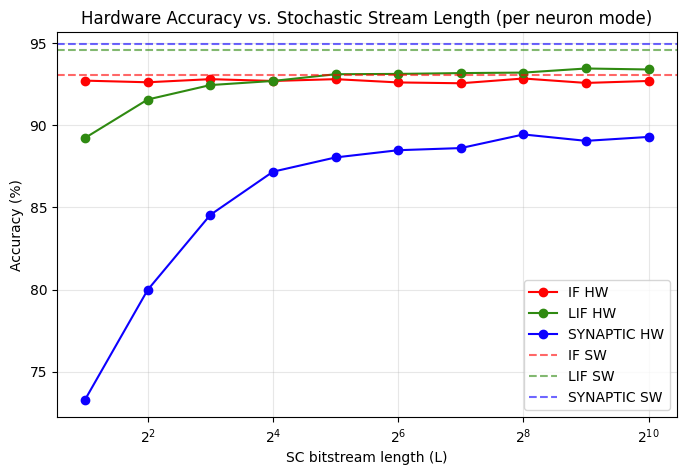

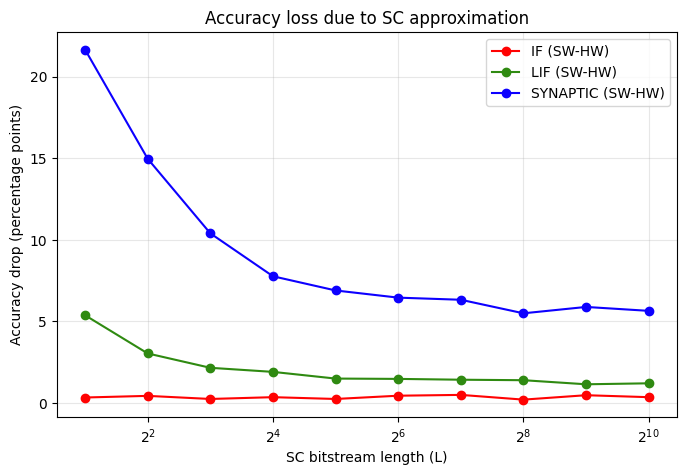

In [9]:
import matplotlib.pyplot as plt

plt.style.use("default")

plt.figure(figsize=(8,5))
for mode, c in zip(MODES, ["#ff0202ff", "#2f8a11ff", "#0d00ffff"]):
    L = np.array(results[mode]["L"])
    mean = np.array(results[mode]["mean"])
    std = np.array(results[mode]["std"])

    plt.plot(L, mean*100, marker="o", label=f"{mode.upper()} HW", color=c)
    plt.fill_between(L, (mean-std)*100, (mean+std)*100, alpha=0.2)

for mode, c in zip(MODES, ["#ff0202ff", "#2f8a11ff", "#0d00ffff"]):
    plt.axhline(results[mode]["software_acc"]*100, linestyle="--", alpha=0.6, label=f"{mode.upper()} SW", color=c)

plt.xscale("log", base=2)
plt.xlabel("SC bitstream length (L)")
plt.ylabel("Accuracy (%)")
plt.title("Hardware Accuracy vs. Stochastic Stream Length (per neuron mode)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.savefig(
    "SW_acc_HW_acc.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()

plt.figure(figsize=(8,5))
for mode, c in zip(MODES, ["#ff0202ff", "#2f8a11ff", "#0d00ffff"]):
    L = np.array(results[mode]["L"])
    drop = (results[mode]["software_acc"] - np.array(results[mode]["mean"])) * 100
    plt.plot(L, drop, marker="o", label=f"{mode.upper()} (SW-HW)", color=c)

plt.xscale("log", base=2)
plt.xlabel("SC bitstream length (L)")
plt.ylabel("Accuracy drop (percentage points)")
plt.title("Accuracy loss due to SC approximation")
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.savefig(
    "SW_acc_HW_acc_loss.svg",
    format="svg",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0
)

plt.show()